# 08-03. Selected External Feature Validation
## Economics 제거 + CatBoost / Tuned MLP 재검증

### 08-02에서 확인한 것

2017+ 동일 sample에서:

```text
C0 Exp9Cb                 MAE ≈ 2.3988
C1 + Market               MAE ≈ 2.3908
C2 + Transfer All         MAE ≈ 2.3983
C3 + All External         MAE ≈ 2.3880
```

그리고 Transfer 내부 ablation에서는:

```text
T1 Transfer State                약간 개선
T2 + Transfer Economics          악화
T3 + State + New-Team            가장 좋음
T4 + Economics + New-Team        T3보다 악화
```

즉 현재 가설은:

> **Market Value + Market Momentum + Transfer State + New-Team Environment는 유지하고,
> Transfer Economics는 제거하는 것이 더 낫지 않을까?**

입니다.

---

# 이번 Notebook의 질문

## Part A — Selected Feature Validation

동일한 2017+ sample, 동일한 fixed CatBoost에서:

```text
S0 Exp9Cb

S1 Market
= Market Value + Momentum

S2 Transfer Context
= Transfer State + New-Team Environment

S3 Selected External
= Market + Transfer State + New-Team Environment
  (Transfer Economics 제외)

S4 All External Reference
= S3 + Transfer Economics
```

를 비교합니다.

### 핵심 비교

```text
S3 vs S0
→ 외부 데이터 전체 가치

S3 vs S4
→ 이적료/fee 계열 제거가 실제로 더 나은가?
```

---

## Part B — Model Revalidation

S3가 유효하다면:

```text
Fixed Baseline CatBoost
vs
07 Tuned MLP hyperparameters 재사용
```

을 비교합니다.

### 중요한 제한

07 MLP hyperparameter를 **다시 튜닝하지 않습니다.**

- architecture
- dropout
- learning rate
- weight decay
- batch size

는 07에서 선택된 Fold별 값을 그대로 사용합니다.

다만 현재 2017+ Outer Train 내부 마지막 시즌으로
**학습 epoch만 다시 calibration**합니다.

---

## Test Lock

Final Test `2024-25 → 2025-26`은 계속 로드하지 않습니다.

## 0. 왜 여기서 조합 탐색을 멈추는가?

Feature 조합을 계속 추가/삭제하면서 같은 Outer Validation을 반복해서 보면
개발 validation 자체에 맞춰진 선택이 될 수 있습니다.

따라서 이번 08-03은:

1. 08-02에서 명확한 가설 하나만 재검증
2. Selected Feature Set 확정
3. CatBoost / MLP 재검증
4. 이후 필요하면 **확정된 feature set에서만** HPO

순서로 진행합니다.

08-03 이후에는 무작위 feature 조합 탐색을 중단합니다.

In [2]:
from pathlib import Path
import json
import random
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)

warnings.filterwarnings("ignore")

SEED = 42

def reset_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)

reset_seed()

print("Seed:", SEED)

Seed: 42


## 1. 라이브러리 확인

In [3]:
try:
    import catboost
    from catboost import CatBoostRegressor

    print("catboost:", catboost.__version__)

except ImportError as exc:
    raise ImportError(
        "catboost가 필요합니다. `pip install catboost` 후 "
        "커널을 재시작하세요."
    ) from exc


try:
    import torch
    import torch.nn as nn

    from torch.utils.data import (
        DataLoader,
        TensorDataset,
    )

    print("torch:", torch.__version__)

except ImportError as exc:
    raise ImportError(
        "PyTorch가 필요합니다."
    ) from exc


DEVICE = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)

catboost: 1.2.10
torch: 2.13.0+cpu
Device: cpu


## 2. 파일 자동 탐색

필요 파일:

```text
08_v2_preseason_player_snapshot_dev.csv
07_mlp_best_params_by_fold.csv
```

08-02 결과 파일도 있으면 이전 결과와 sanity check합니다.

In [4]:
MANUAL_SNAPSHOT_PATH = None
MANUAL_MLP_PARAMS_PATH = None
MANUAL_08_02_SUMMARY_PATH = None

SEARCH_ROOTS = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd().parent.parent,
]

SEARCH_ROOTS = list(
    dict.fromkeys(
        p.resolve()
        for p in SEARCH_ROOTS
        if p.exists()
    )
)


def find_named_file(filename):
    candidates = []

    for root in SEARCH_ROOTS:
        try:
            for path in root.rglob(
                filename
            ):
                if path.is_file():
                    candidates.append(
                        path
                    )
        except (
            PermissionError,
            OSError,
        ):
            continue

    if not candidates:
        return None

    candidates.sort(
        key=lambda p: (
            len(str(p)),
            str(p),
        )
    )

    return candidates[0]


def resolve_path(
    manual,
    filename,
    required=True,
):
    if manual is not None:
        path = Path(manual)

        if not path.exists():
            raise FileNotFoundError(
                path
            )

        return path

    path = find_named_file(
        filename
    )

    if (
        required
        and path is None
    ):
        raise FileNotFoundError(
            f"{filename}을 찾지 못했습니다."
        )

    return path


SNAPSHOT_PATH = resolve_path(
    MANUAL_SNAPSHOT_PATH,
    "08_v2_preseason_player_snapshot_dev.csv",
)

MLP_PARAMS_PATH = resolve_path(
    MANUAL_MLP_PARAMS_PATH,
    "07_mlp_best_params_by_fold.csv",
)

SUMMARY_08_02_PATH = resolve_path(
    MANUAL_08_02_SUMMARY_PATH,
    "08_02_external_ablation_summary.csv",
    required=False,
)

print(
    "Snapshot:",
    SNAPSHOT_PATH,
)

print(
    "07 MLP params:",
    MLP_PARAMS_PATH,
)

print(
    "08-02 summary:",
    SUMMARY_08_02_PATH,
)

Snapshot: D:\dev\03_PersonalProjects\next_season_goal_prediction\notebooks\artifacts\08_v2_preseason_player_snapshot_dev.csv
07 MLP params: D:\dev\03_PersonalProjects\next_season_goal_prediction\notebooks\artifacts\07_mlp_best_params_by_fold.csv
08-02 summary: D:\dev\03_PersonalProjects\next_season_goal_prediction\notebooks\artifacts\08_02_external_ablation_summary.csv


In [5]:
df = pd.read_csv(
    SNAPSHOT_PATH,
    low_memory=False,
)

mlp_params_df = (
    pd.read_csv(
        MLP_PARAMS_PATH
    )
)

print(
    "Snapshot shape:",
    df.shape,
)

print("\n07 MLP Fold params")
display(
    mlp_params_df
)

assert (
    set(
        mlp_params_df[
            "fold"
        ].astype(int)
    )
    == {1, 2, 3, 4}
)

Snapshot shape: (23353, 114)

07 MLP Fold params


,fold,architecture_name,dropout,learning_rate,weight_decay,batch_size
0,1,256_128_64,0.152337,0.001498,0.000407,32
1,2,256_128_64,0.023367,0.002726,0.000001,128
2,3,256_128_64,0.064885,0.001020,0.000509,128
3,4,256_128_64,0.177845,0.002827,0.000083,128


## 3. 07 Tuned MLP 설정

07 결과의 4개 Fold 모두 architecture는:

```text
256 → 128 → 64
```

였습니다.

나머지 설정은 Fold별로 고정해서 재사용합니다.

이 값들은 **08-03 Outer Validation을 보고 선택하는 값이 아닙니다.**
이미 07에서 정해진 설정입니다.

In [6]:
MLP_ARCHITECTURES = {
    "64_32": [
        64,
        32,
    ],
    "128_64": [
        128,
        64,
    ],
    "128_64_32": [
        128,
        64,
        32,
    ],
    "256_128_64": [
        256,
        128,
        64,
    ],
}


def get_mlp_params_for_fold(
    fold_id,
):
    row = (
        mlp_params_df[
            mlp_params_df[
                "fold"
            ].astype(int)
            .eq(
                int(fold_id)
            )
        ]
        .iloc[0]
    )

    architecture_name = str(
        row[
            "architecture_name"
        ]
    )

    return {
        "architecture_name": (
            architecture_name
        ),
        "hidden_dims": (
            MLP_ARCHITECTURES[
                architecture_name
            ]
        ),
        "dropout": float(
            row["dropout"]
        ),
        "learning_rate": float(
            row[
                "learning_rate"
            ]
        ),
        "weight_decay": float(
            row[
                "weight_decay"
            ]
        ),
        "batch_size": int(
            row["batch_size"]
        ),
    }


for fold_id in range(
    1,
    5,
):
    print(
        "Fold",
        fold_id,
        get_mlp_params_for_fold(
            fold_id
        ),
    )

Fold 1 {'architecture_name': '256_128_64', 'hidden_dims': [256, 128, 64], 'dropout': 0.1523373539456242, 'learning_rate': 0.0014981723596616, 'weight_decay': 0.0004072257787123, 'batch_size': 32}
Fold 2 {'architecture_name': '256_128_64', 'hidden_dims': [256, 128, 64], 'dropout': 0.0233668962175098, 'learning_rate': 0.0027259155172982, 'weight_decay': 1.2196061876085765e-06, 'batch_size': 128}
Fold 3 {'architecture_name': '256_128_64', 'hidden_dims': [256, 128, 64], 'dropout': 0.0648846844358834, 'learning_rate': 0.0010203339829786, 'weight_decay': 0.0005091037041881, 'batch_size': 128}
Fold 4 {'architecture_name': '256_128_64', 'hidden_dims': [256, 128, 64], 'dropout': 0.1778447890913186, 'learning_rate': 0.0028267525438625, 'weight_decay': 8.318308206340892e-05, 'batch_size': 128}


## 4. 08-02 결과 sanity check

이 셀은 08-02 CSV가 있을 때만 실행됩니다.

목표는 이번 Notebook의 출발 가설이
실제 저장 결과와 일치하는지 확인하는 것입니다.

In [7]:
if (
    SUMMARY_08_02_PATH
    is not None
):
    previous_summary = (
        pd.read_csv(
            SUMMARY_08_02_PATH
        )
    )

    display(
        previous_summary[
            [
                "family",
                "experiment",
                "mae_mean",
                "10plus_mae_mean",
                "changed_team_mae_mean",
            ]
        ]
    )

else:
    print(
        "08-02 summary file 없음 "
        "→ 이 셀은 건너뜁니다."
    )

,family,experiment,mae_mean,10plus_mae_mean,changed_team_mae_mean
0,Combined_2017plus,C3_all_external,2.387970,6.435203,2.731269
1,Combined_2017plus,C1_all_market,2.390787,6.438716,2.752900
2,Combined_2017plus,C2_all_transfer,2.398255,6.440468,2.753545
3,Combined_2017plus,C0_Exp9Cb,2.398809,6.445676,2.756612
4,Market_2005plus,M0_Exp9Cb,2.385121,6.254958,2.688659
5,Market_2005plus,M2_plus_market_momentum,2.395903,6.120676,2.752889
6,Market_2005plus,M1_plus_market_value,2.396318,6.111878,2.748550
7,Transfer_2017plus,T3_plus_state_new_team,2.392630,6.430194,2.740936
8,Transfer_2017plus,T1_plus_transfer_state,2.397902,6.492227,2.760305
9,Transfer_2017plus,T4_all_transfer_context,2.398255,6.440468,2.753545


# Part A. 2017+ Development Sample

## 5. Exp9Cb Historical Feature 재생성

08-02와 동일한 방식으로 재생성합니다.

In [8]:
df["season_start"] = (
    df["season"]
    .astype(str)
    .str[:4]
    .astype(int)
)

df["target_year"] = (
    df["target_season"]
    .astype(str)
    .str[:4]
    .astype(int)
)

df = (
    df
    .sort_values(
        [
            "player",
            "season_start",
        ]
    )
    .reset_index(
        drop=True
    )
)

player_group = (
    df.groupby(
        "player",
        sort=False,
    )
)

df[
    "goals_3yr_mean"
] = player_group[
    "goals"
].transform(
    lambda s:
        s.shift(1)
        .rolling(
            window=3,
            min_periods=1,
        )
        .mean()
)

df[
    "goals_per90_3yr_mean"
] = player_group[
    "goals_per90"
].transform(
    lambda s:
        s.shift(1)
        .rolling(
            window=3,
            min_periods=1,
        )
        .mean()
)

df[
    "goals_3yr_max"
] = player_group[
    "goals"
].transform(
    lambda s:
        s.shift(1)
        .rolling(
            window=3,
            min_periods=1,
        )
        .max()
)

HISTORICAL_COLS = [
    "goals_3yr_mean",
    "goals_per90_3yr_mean",
    "goals_3yr_max",
]

df[
    HISTORICAL_COLS
] = (
    df[
        HISTORICAL_COLS
    ]
    .fillna(0.0)
)

## 6. Conditional Model B + 2017+

회귀 모집단:

```text
matched_next == True
```

Transfer data quality 조건:

```text
target_year >= 2017
```

을 동시에 적용합니다.

In [9]:
model_df = (
    df[
        df[
            "matched_next"
        ].eq(True)
        & df[
            "target_year"
        ].ge(2017)
    ]
    .copy()
)

model_df = (
    model_df
    .sort_values(
        [
            "season_start",
            "player",
        ]
    )
    .reset_index(
        drop=True
    )
)

print(
    "Rows:",
    len(model_df),
)

print(
    "Season:",
    model_df[
        "season"
    ].min(),
    "~",
    model_df[
        "season"
    ].max(),
)

print(
    "Changed-team rate:",
    f"{model_df['changed_team_preseason'].mean():.2%}"
)

Rows: 6371
Season: 2016-2017 ~ 2023-2024
Changed-team rate: 9.98%


## 7. Final Test Lock

In [10]:
assert (
    "2024-2025"
    not in set(
        model_df[
            "season"
        ].astype(str)
    )
)

print(
    "✅ Final Test 2024-25 → 2025-26 remains locked."
)

✅ Final Test 2024-25 → 2025-26 remains locked.


# Part B. Feature Set

In [11]:
BASE_NUMERIC = [
    "age",
    "starts",
    "minutes",
    "goals",
    "assists",
    "non_penalty_goals",
    "penalty_goals",
    "penalty_attempts",
    "goals_per90",
    "assists_per90",
    "goal_contrib_per90",
]

TEAM_BASE_FEATURES = [
    "old_team_rank_pct",
    "old_team_points_per_game",
    "old_team_goal_diff_per_game",
]

EXP9CB_NUMERIC = (
    BASE_NUMERIC
    + HISTORICAL_COLS
    + TEAM_BASE_FEATURES
)

BASE_CATEGORICAL = [
    "league",
    "position_group",
]

TARGET = "next_goals"

MARKET_VALUE_FEATURES = [
    "market_value_known",
    "log_market_value",
    "market_value_percentile",
    "market_value_vs_position_median",
]

MARKET_MOMENTUM_FEATURES = [
    "market_value_growth_6m",
    "market_value_growth_12m",
    "market_value_vs_peak",
]

TRANSFER_STATE_FEATURES = [
    "changed_team_preseason",
    "same_league_transfer",
    "league_changed",
    "country_changed",
    "is_loan_preseason",
    "days_since_transfer",
]

TRANSFER_ECONOMIC_FEATURES = [
    "transfer_fee_known",
    "log_transfer_fee",
    "fee_to_transfer_market_value_ratio",
]

NEW_TEAM_ENVIRONMENT_FEATURES = [
    "new_team_prev_rank_pct",
    "new_team_prev_points_per_game",
    "new_team_prev_goal_diff_per_game",
    "team_rank_change",
    "team_points_change",
    "team_goal_diff_change",
    "new_team_strength_missing",
]

MARKET_ALL = (
    MARKET_VALUE_FEATURES
    + MARKET_MOMENTUM_FEATURES
)

TRANSFER_SELECTED = (
    TRANSFER_STATE_FEATURES
    + NEW_TEAM_ENVIRONMENT_FEATURES
)

SELECTED_EXTERNAL = (
    MARKET_ALL
    + TRANSFER_SELECTED
)

ALL_EXTERNAL_WITH_ECONOMICS = (
    SELECTED_EXTERNAL
    + TRANSFER_ECONOMIC_FEATURES
)

SELECTED_EXPERIMENTS = {
    "S0_Exp9Cb": (
        EXP9CB_NUMERIC
    ),

    "S1_market": (
        EXP9CB_NUMERIC
        + MARKET_ALL
    ),

    "S2_transfer_new_team": (
        EXP9CB_NUMERIC
        + TRANSFER_SELECTED
    ),

    "S3_selected_no_economics": (
        EXP9CB_NUMERIC
        + SELECTED_EXTERNAL
    ),

    "S4_all_with_economics": (
        EXP9CB_NUMERIC
        + ALL_EXTERNAL_WITH_ECONOMICS
    ),
}

for name, features in (
    SELECTED_EXPERIMENTS.items()
):
    print(
        f"{name:<28}",
        len(features),
        "numeric",
    )

S0_Exp9Cb                    17 numeric
S1_market                    24 numeric
S2_transfer_new_team         30 numeric
S3_selected_no_economics     37 numeric
S4_all_with_economics        40 numeric


## 8. Feature Missingness

In [12]:
missingness = (
    model_df[
        list(
            dict.fromkeys(
                SELECTED_EXTERNAL
                + TRANSFER_ECONOMIC_FEATURES
            )
        )
    ]
    .isna()
    .mean()
    .sort_values(
        ascending=False
    )
    .rename(
        "missing_rate"
    )
    .to_frame()
)

missingness

,missing_rate
fee_to_transfer_market_value_ratio,0.875216
log_transfer_fee,0.875216
days_since_transfer,0.873960
market_value_growth_12m,0.058547
market_value_growth_6m,0.054466
market_value_vs_position_median,0.053995
log_market_value,0.053995
market_value_percentile,0.053995
market_value_vs_peak,0.053995
team_points_change,0.032491


# Part C. 공통 Evaluation

In [13]:
OUTER_VAL_SEASONS = [
    "2020-2021",
    "2021-2022",
    "2022-2023",
    "2023-2024",
]


def regression_metrics(
    y_true,
    y_pred,
):
    y_true = np.asarray(
        y_true,
        dtype=float,
    )

    y_pred = np.asarray(
        y_pred,
        dtype=float,
    )

    return {
        "mae": mean_absolute_error(
            y_true,
            y_pred,
        ),
        "rmse": (
            mean_squared_error(
                y_true,
                y_pred,
            ) ** 0.5
        ),
        "r2": r2_score(
            y_true,
            y_pred,
        ),
        "bias": float(
            np.mean(
                y_pred - y_true
            )
        ),
    }


def slice_metrics(
    y_true,
    y_pred,
    mask,
):
    y_true = np.asarray(
        y_true,
        dtype=float,
    )

    y_pred = np.asarray(
        y_pred,
        dtype=float,
    )

    mask = np.asarray(
        mask,
        dtype=bool,
    )

    if mask.sum() == 0:
        return {
            "n": 0,
            "mae": np.nan,
            "bias": np.nan,
        }

    return {
        "n": int(
            mask.sum()
        ),
        "mae": mean_absolute_error(
            y_true[mask],
            y_pred[mask],
        ),
        "bias": float(
            np.mean(
                y_pred[mask]
                - y_true[mask]
            )
        ),
    }


def add_slice_metrics(
    result_row,
    val_df,
    y_true,
    pred,
):
    for threshold in [
        10,
        15,
        20,
    ]:
        h = slice_metrics(
            y_true,
            pred,
            y_true >= threshold,
        )

        result_row[
            f"{threshold}plus_n"
        ] = h["n"]

        result_row[
            f"{threshold}plus_mae"
        ] = h["mae"]

        result_row[
            f"{threshold}plus_bias"
        ] = h["bias"]

    changed_mask = (
        val_df[
            "changed_team_preseason"
        ]
        .fillna(0)
        .astype(int)
        .eq(1)
        .to_numpy()
    )

    changed = slice_metrics(
        y_true,
        pred,
        changed_mask,
    )

    same_team = slice_metrics(
        y_true,
        pred,
        ~changed_mask,
    )

    result_row[
        "changed_team_n"
    ] = changed["n"]

    result_row[
        "changed_team_mae"
    ] = changed["mae"]

    result_row[
        "changed_team_bias"
    ] = changed["bias"]

    result_row[
        "same_team_n"
    ] = same_team["n"]

    result_row[
        "same_team_mae"
    ] = same_team["mae"]

    result_row[
        "same_team_bias"
    ] = same_team["bias"]

    return result_row

# Part D. Fixed CatBoost Selected Ablation

## 9. CatBoost 준비

08-02와 같은 fixed baseline 설정입니다.

Outer Validation은 early stopping에 사용하지 않습니다.
Outer Train의 마지막 시즌으로 iteration만 결정합니다.

In [14]:
CATBOOST_MAX_ITER = 2000
CATBOOST_PATIENCE = 50

FIXED_CATBOOST_PARAMS = {
    "depth": 6,
    "learning_rate": 0.03,
    "loss_function": "RMSE",
}


def prepare_catboost_xy(
    data,
    numeric_features,
):
    feature_cols = (
        numeric_features
        + BASE_CATEGORICAL
    )

    X = data[
        feature_cols
    ].copy()

    for col in (
        BASE_CATEGORICAL
    ):
        X[col] = (
            X[col]
            .fillna(
                "__MISSING__"
            )
            .astype(str)
        )

    for col in numeric_features:
        X[col] = pd.to_numeric(
            X[col],
            errors="coerce",
        )

    y = (
        data[
            TARGET
        ]
        .to_numpy(
            dtype=np.float32
        )
    )

    cat_indices = [
        X.columns.get_loc(
            c
        )
        for c in (
            BASE_CATEGORICAL
        )
    ]

    return (
        X,
        y,
        cat_indices,
    )


def fit_fixed_catboost(
    outer_train_df,
    outer_val_df,
    numeric_features,
    seed,
):
    calibration_val_start = (
        outer_train_df[
            "season_start"
        ].max()
    )

    cal_train = (
        outer_train_df[
            outer_train_df[
                "season_start"
            ]
            < calibration_val_start
        ]
        .copy()
    )

    cal_val = (
        outer_train_df[
            outer_train_df[
                "season_start"
            ]
            == calibration_val_start
        ]
        .copy()
    )

    (
        X_cal_train,
        y_cal_train,
        cat_indices,
    ) = prepare_catboost_xy(
        cal_train,
        numeric_features,
    )

    (
        X_cal_val,
        y_cal_val,
        _,
    ) = prepare_catboost_xy(
        cal_val,
        numeric_features,
    )

    selector = (
        CatBoostRegressor(
            iterations=(
                CATBOOST_MAX_ITER
            ),
            eval_metric="MAE",
            random_seed=seed,
            verbose=False,
            allow_writing_files=False,
            **FIXED_CATBOOST_PARAMS,
        )
    )

    selector.fit(
        X_cal_train,
        y_cal_train,
        cat_features=(
            cat_indices
        ),
        eval_set=(
            X_cal_val,
            y_cal_val,
        ),
        early_stopping_rounds=(
            CATBOOST_PATIENCE
        ),
        use_best_model=True,
        verbose=False,
    )

    selected_iterations = max(
        1,
        int(
            selector.get_best_iteration()
        )
        + 1,
    )

    (
        X_train,
        y_train,
        cat_indices,
    ) = prepare_catboost_xy(
        outer_train_df,
        numeric_features,
    )

    (
        X_val,
        y_val,
        _,
    ) = prepare_catboost_xy(
        outer_val_df,
        numeric_features,
    )

    model = (
        CatBoostRegressor(
            iterations=(
                selected_iterations
            ),
            random_seed=seed,
            verbose=False,
            allow_writing_files=False,
            **FIXED_CATBOOST_PARAMS,
        )
    )

    start = (
        time.perf_counter()
    )

    model.fit(
        X_train,
        y_train,
        cat_features=(
            cat_indices
        ),
        verbose=False,
    )

    pred = model.predict(
        X_val
    )

    elapsed = (
        time.perf_counter()
        - start
    )

    return {
        "y_true": y_val,
        "pred": pred,
        "selected_rounds": (
            selected_iterations
        ),
        "fit_seconds": elapsed,
    }

## 10. CatBoost S0~S4 실행

In [15]:
catboost_rows = []
catboost_predictions = []

for fold_id, outer_val_season in enumerate(
    OUTER_VAL_SEASONS,
    start=1,
):
    val_start = int(
        outer_val_season[:4]
    )

    outer_train_df = (
        model_df[
            model_df[
                "season_start"
            ]
            < val_start
        ]
        .copy()
    )

    outer_val_df = (
        model_df[
            model_df[
                "season_start"
            ]
            == val_start
        ]
        .copy()
    )

    print(
        "\n"
        + "=" * 90
    )

    print(
        f"CatBoost Fold {fold_id} | "
        f"{outer_val_season} | "
        f"Train {len(outer_train_df):,} | "
        f"Val {len(outer_val_df):,}"
    )

    print(
        "=" * 90
    )

    for (
        experiment,
        numeric_features,
    ) in (
        SELECTED_EXPERIMENTS.items()
    ):
        result = fit_fixed_catboost(
            outer_train_df,
            outer_val_df,
            numeric_features,
            seed=(
                SEED
                + fold_id * 100
            ),
        )

        metrics = regression_metrics(
            result["y_true"],
            result["pred"],
        )

        row = {
            "model": (
                "Fixed_CatBoost"
            ),
            "experiment": (
                experiment
            ),
            "fold": fold_id,
            "outer_val_season": (
                outer_val_season
            ),
            "train_n": len(
                outer_train_df
            ),
            "val_n": len(
                outer_val_df
            ),
            "numeric_feature_count": (
                len(
                    numeric_features
                )
            ),
            "selected_rounds": (
                result[
                    "selected_rounds"
                ]
            ),
            "fit_seconds": (
                result[
                    "fit_seconds"
                ]
            ),
            **metrics,
        }

        row = add_slice_metrics(
            row,
            outer_val_df,
            result[
                "y_true"
            ],
            result[
                "pred"
            ],
        )

        catboost_rows.append(
            row
        )

        pred_df = (
            outer_val_df[
                [
                    "player",
                    "season",
                    "target_season",
                    "team",
                    "destination_team",
                    "changed_team_preseason",
                    "market_value_preseason_eur",
                    "next_goals",
                ]
            ]
            .copy()
        )

        pred_df[
            "model"
        ] = "Fixed_CatBoost"

        pred_df[
            "experiment"
        ] = experiment

        pred_df[
            "fold"
        ] = fold_id

        pred_df[
            "prediction"
        ] = result[
            "pred"
        ]

        catboost_predictions.append(
            pred_df
        )

        print(
            f"{experiment:<28} | "
            f"MAE {metrics['mae']:.4f} | "
            f"10+ {row['10plus_mae']:.4f} | "
            f"Changed {row['changed_team_mae']:.4f}"
        )


catboost_results = (
    pd.DataFrame(
        catboost_rows
    )
)

catboost_prediction_df = (
    pd.concat(
        catboost_predictions,
        ignore_index=True,
    )
)


CatBoost Fold 1 | 2020-2021 | Train 3,252 | Val 834
S0_Exp9Cb                    | MAE 2.3368 | 10+ 5.9924 | Changed 2.4143
S1_market                    | MAE 2.3383 | 10+ 6.0355 | Changed 2.4461
S2_transfer_new_team         | MAE 2.3299 | 10+ 5.9046 | Changed 2.3877
S3_selected_no_economics     | MAE 2.3243 | 10+ 5.9377 | Changed 2.3625
S4_all_with_economics        | MAE 2.3282 | 10+ 5.9879 | Changed 2.4236

CatBoost Fold 2 | 2021-2022 | Train 4,086 | Val 778
S0_Exp9Cb                    | MAE 2.4816 | 10+ 6.5687 | Changed 3.0198
S1_market                    | MAE 2.4716 | 10+ 6.5426 | Changed 3.0075
S2_transfer_new_team         | MAE 2.4787 | 10+ 6.5595 | Changed 2.9607
S3_selected_no_economics     | MAE 2.4580 | 10+ 6.4627 | Changed 2.9423
S4_all_with_economics        | MAE 2.4601 | 10+ 6.5169 | Changed 3.0041

CatBoost Fold 3 | 2022-2023 | Train 4,864 | Val 738
S0_Exp9Cb                    | MAE 2.3353 | 10+ 6.6458 | Changed 2.4217
S1_market                    | MAE 2.3125 | 10+ 6

## 11. CatBoost Summary

In [16]:
def summarize_model_results(
    results,
):
    rows = []

    for (
        model,
        experiment,
    ), g in (
        results.groupby(
            [
                "model",
                "experiment",
            ]
        )
    ):
        rows.append({
            "model": model,
            "experiment": (
                experiment
            ),
            "folds": (
                g["fold"].nunique()
            ),
            "mae_mean": (
                g["mae"].mean()
            ),
            "mae_std": (
                g["mae"].std(
                    ddof=1
                )
            ),
            "mae_worst": (
                g["mae"].max()
            ),
            "rmse_mean": (
                g["rmse"].mean()
            ),
            "r2_mean": (
                g["r2"].mean()
            ),
            "bias_mean": (
                g["bias"].mean()
            ),
            "10plus_mae_mean": (
                g[
                    "10plus_mae"
                ].mean()
            ),
            "10plus_bias_mean": (
                g[
                    "10plus_bias"
                ].mean()
            ),
            "15plus_mae_mean": (
                g[
                    "15plus_mae"
                ].mean()
            ),
            "20plus_mae_mean": (
                g[
                    "20plus_mae"
                ].mean()
            ),
            "changed_team_mae_mean": (
                g[
                    "changed_team_mae"
                ].mean()
            ),
            "changed_team_bias_mean": (
                g[
                    "changed_team_bias"
                ].mean()
            ),
            "same_team_mae_mean": (
                g[
                    "same_team_mae"
                ].mean()
            ),
        })

    return (
        pd.DataFrame(
            rows
        )
        .sort_values(
            [
                "mae_mean",
            ]
        )
        .reset_index(
            drop=True
        )
    )


catboost_summary = (
    summarize_model_results(
        catboost_results
    )
)

catboost_summary

,model,experiment,folds,mae_mean,mae_std,mae_worst,rmse_mean,r2_mean,bias_mean,10plus_mae_mean,10plus_bias_mean,15plus_mae_mean,20plus_mae_mean,changed_team_mae_mean,changed_team_bias_mean,same_team_mae_mean
0,Fixed_CatBoost,S3_selected_no_economics,4,2.382645,0.078475,2.458011,3.424914,0.461745,-0.010918,6.415246,-5.972970,8.645465,10.902247,2.721635,0.034598,2.333862
1,Fixed_CatBoost,S4_all_with_economics,4,2.385486,0.076357,2.460112,3.440263,0.456895,-0.005282,6.426842,-5.963972,8.684922,11.043590,2.761516,0.033642,2.332315
2,Fixed_CatBoost,S1_market,4,2.390787,0.077266,2.471609,3.428409,0.460707,-0.013283,6.438716,-5.968845,8.631400,10.941671,2.752900,0.114147,2.339925
3,Fixed_CatBoost,S2_transfer_new_team,4,2.392630,0.080826,2.478733,3.449802,0.453835,-0.009844,6.430194,-5.969466,8.615334,10.997648,2.740936,0.025262,2.342996
4,Fixed_CatBoost,S0_Exp9Cb,4,2.398809,0.074314,2.481577,3.444533,0.455485,-0.011564,6.445676,-5.964375,8.671721,11.098047,2.756612,0.106929,2.348008


## 12. 핵심 S3 vs S4 직접 비교

S3가 S4보다 같거나 좋다면
08-02에서 의심했던 Transfer Economics 제거 가설을 지지합니다.

In [17]:
comparison_s3_s4 = (
    catboost_results[
        catboost_results[
            "experiment"
        ].isin(
            [
                "S3_selected_no_economics",
                "S4_all_with_economics",
            ]
        )
    ]
    .pivot(
        index="outer_val_season",
        columns="experiment",
        values="mae",
    )
)

comparison_s3_s4[
    "S3_minus_S4"
] = (
    comparison_s3_s4[
        "S3_selected_no_economics"
    ]
    - comparison_s3_s4[
        "S4_all_with_economics"
    ]
)

comparison_s3_s4

experiment,S3_selected_no_economics,S4_all_with_economics,S3_minus_S4
outer_val_season,,,
2020-2021,2.324305,2.328185,-0.003880
2021-2022,2.458011,2.460112,-0.002101
2022-2023,2.306137,2.311674,-0.005537
2023-2024,2.442126,2.441971,0.000155


# Part E. 07 Tuned MLP 재검증

## 13. MLP Preprocessing

07에서는:

```text
StandardScaler
+
OneHotEncoder(handle_unknown="ignore")
```

를 사용했습니다.

08-03 external numeric feature에는 결측치가 있기 때문에,
MLP에서만 다음을 추가합니다.

```text
Train median imputation
→ StandardScaler
```

중요:

- median은 각 Outer Train에서만 학습
- Outer Validation 정보는 imputation에 사용하지 않음
- CatBoost는 원래처럼 NaN을 직접 처리

따라서 leakage는 발생하지 않습니다.

In [18]:
def make_mlp_preprocessor(
    numeric_features,
):
    numeric_pipeline = (
        Pipeline(
            steps=[
                (
                    "imputer",
                    SimpleImputer(
                        strategy="median",
                    ),
                ),
                (
                    "scaler",
                    StandardScaler(),
                ),
            ]
        )
    )

    return ColumnTransformer(
        transformers=[
            (
                "num",
                numeric_pipeline,
                numeric_features,
            ),
            (
                "cat",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False,
                ),
                BASE_CATEGORICAL,
            ),
        ],
        remainder="drop",
        verbose_feature_names_out=True,
    )


def mlp_fit_transform(
    train_df,
    eval_df,
    numeric_features,
):
    feature_cols = (
        numeric_features
        + BASE_CATEGORICAL
    )

    preprocessor = (
        make_mlp_preprocessor(
            numeric_features
        )
    )

    X_train = (
        preprocessor.fit_transform(
            train_df[
                feature_cols
            ]
        )
    )

    X_eval = (
        preprocessor.transform(
            eval_df[
                feature_cols
            ]
        )
    )

    y_train = (
        train_df[
            TARGET
        ]
        .to_numpy(
            dtype=np.float32
        )
    )

    y_eval = (
        eval_df[
            TARGET
        ]
        .to_numpy(
            dtype=np.float32
        )
    )

    return (
        X_train,
        X_eval,
        y_train,
        y_eval,
        preprocessor,
    )

## 14. Flexible MLP — 07과 동일 구조

In [19]:
def reset_torch_seed(
    seed=SEED,
):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(
            seed
        )


class FlexibleMLP(
    nn.Module
):
    def __init__(
        self,
        input_dim,
        hidden_dims,
        dropout=0.0,
    ):
        super().__init__()

        layers = []
        prev_dim = input_dim

        for hidden_dim in (
            hidden_dims
        ):
            layers.append(
                nn.Linear(
                    prev_dim,
                    hidden_dim,
                )
            )

            layers.append(
                nn.ReLU()
            )

            if dropout > 0:
                layers.append(
                    nn.Dropout(
                        dropout
                    )
                )

            prev_dim = (
                hidden_dim
            )

        layers.append(
            nn.Linear(
                prev_dim,
                1,
            )
        )

        self.net = (
            nn.Sequential(
                *layers
            )
        )

    def forward(
        self,
        x,
    ):
        return self.net(x)


def make_loader(
    X,
    y,
    batch_size,
    shuffle=False,
):
    X_t = torch.tensor(
        X,
        dtype=torch.float32,
    )

    y_t = torch.tensor(
        y,
        dtype=torch.float32,
    ).reshape(
        -1,
        1,
    )

    dataset = TensorDataset(
        X_t,
        y_t,
    )

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
    )

## 15. Epoch Calibration

07과 같은 원칙:

```text
Outer Train
    ↓
마지막 시즌 = calibration validation
그 이전 시즌 = calibration train
    ↓
Validation MAE early stopping
    ↓
best epoch 결정
    ↓
Outer Train 전체 재학습
```

Outer Validation은 epoch 결정에 사용하지 않습니다.

In [20]:
MLP_MAX_EPOCHS = 120
MLP_PATIENCE = 12


def find_mlp_epoch(
    outer_train_df,
    numeric_features,
    params,
    seed,
):
    calibration_val_start = (
        outer_train_df[
            "season_start"
        ].max()
    )

    cal_train = (
        outer_train_df[
            outer_train_df[
                "season_start"
            ]
            < calibration_val_start
        ]
        .copy()
    )

    cal_val = (
        outer_train_df[
            outer_train_df[
                "season_start"
            ]
            == calibration_val_start
        ]
        .copy()
    )

    reset_torch_seed(
        seed
    )

    (
        X_train,
        X_val,
        y_train,
        y_val,
        _,
    ) = mlp_fit_transform(
        cal_train,
        cal_val,
        numeric_features,
    )

    train_loader = (
        make_loader(
            X_train,
            y_train,
            batch_size=(
                params[
                    "batch_size"
                ]
            ),
            shuffle=True,
        )
    )

    model = FlexibleMLP(
        input_dim=(
            X_train.shape[1]
        ),
        hidden_dims=(
            params[
                "hidden_dims"
            ]
        ),
        dropout=(
            params[
                "dropout"
            ]
        ),
    ).to(
        DEVICE
    )

    criterion = (
        nn.MSELoss()
    )

    optimizer = (
        torch.optim.Adam(
            model.parameters(),
            lr=(
                params[
                    "learning_rate"
                ]
            ),
            weight_decay=(
                params[
                    "weight_decay"
                ]
            ),
        )
    )

    best_mae = float(
        "inf"
    )

    best_epoch = 1
    patience_count = 0

    X_val_t = torch.tensor(
        X_val,
        dtype=torch.float32,
        device=DEVICE,
    )

    for epoch in range(
        1,
        MLP_MAX_EPOCHS + 1,
    ):
        model.train()

        for X_b, y_b in (
            train_loader
        ):
            X_b = X_b.to(
                DEVICE
            )

            y_b = y_b.to(
                DEVICE
            )

            optimizer.zero_grad()

            pred = model(
                X_b
            )

            loss = criterion(
                pred,
                y_b,
            )

            loss.backward()
            optimizer.step()

        model.eval()

        with torch.no_grad():
            val_pred = (
                model(
                    X_val_t
                )
                .cpu()
                .numpy()
                .ravel()
            )

        val_mae = (
            mean_absolute_error(
                y_val,
                val_pred,
            )
        )

        if (
            val_mae
            < best_mae - 1e-8
        ):
            best_mae = (
                val_mae
            )

            best_epoch = (
                epoch
            )

            patience_count = 0

        else:
            patience_count += 1

        if (
            patience_count
            >= MLP_PATIENCE
        ):
            break

    return {
        "best_epoch": (
            best_epoch
        ),
        "best_mae": (
            best_mae
        ),
        "epochs_executed": (
            epoch
        ),
    }

## 16. Full Outer Train 재학습 함수

In [21]:
def fit_frozen_tuned_mlp(
    outer_train_df,
    outer_val_df,
    numeric_features,
    params,
    seed,
):
    calibration = (
        find_mlp_epoch(
            outer_train_df,
            numeric_features,
            params,
            seed=seed,
        )
    )

    selected_epoch = int(
        calibration[
            "best_epoch"
        ]
    )

    reset_torch_seed(
        seed
    )

    (
        X_train,
        X_val,
        y_train,
        y_val,
        preprocessor,
    ) = mlp_fit_transform(
        outer_train_df,
        outer_val_df,
        numeric_features,
    )

    train_loader = (
        make_loader(
            X_train,
            y_train,
            batch_size=(
                params[
                    "batch_size"
                ]
            ),
            shuffle=True,
        )
    )

    model = FlexibleMLP(
        input_dim=(
            X_train.shape[1]
        ),
        hidden_dims=(
            params[
                "hidden_dims"
            ]
        ),
        dropout=(
            params[
                "dropout"
            ]
        ),
    ).to(
        DEVICE
    )

    criterion = (
        nn.MSELoss()
    )

    optimizer = (
        torch.optim.Adam(
            model.parameters(),
            lr=(
                params[
                    "learning_rate"
                ]
            ),
            weight_decay=(
                params[
                    "weight_decay"
                ]
            ),
        )
    )

    start = (
        time.perf_counter()
    )

    for _ in range(
        selected_epoch
    ):
        model.train()

        for X_b, y_b in (
            train_loader
        ):
            X_b = X_b.to(
                DEVICE
            )

            y_b = y_b.to(
                DEVICE
            )

            optimizer.zero_grad()

            pred = model(
                X_b
            )

            loss = criterion(
                pred,
                y_b,
            )

            loss.backward()
            optimizer.step()

    model.eval()

    with torch.no_grad():
        pred = (
            model(
                torch.tensor(
                    X_val,
                    dtype=torch.float32,
                    device=DEVICE,
                )
            )
            .cpu()
            .numpy()
            .ravel()
        )

    elapsed = (
        time.perf_counter()
        - start
    )

    return {
        "y_true": y_val,
        "pred": pred,
        "selected_rounds": (
            selected_epoch
        ),
        "calibration_mae": (
            calibration[
                "best_mae"
            ]
        ),
        "fit_seconds": (
            elapsed
        ),
        "input_dim": (
            X_train.shape[1]
        ),
    }

## 17. MLP는 S0와 S3만 재검증

모든 feature 조합을 MLP로 다시 돌리면
다시 feature 탐색이 시작됩니다.

따라서 명확한 비교만 합니다.

```text
MLP_S0
07 Tuned MLP + Exp9Cb

MLP_S3
07 Tuned MLP + Selected External
```

In [22]:
MLP_EXPERIMENTS = {
    "S0_Exp9Cb": (
        EXP9CB_NUMERIC
    ),

    "S3_selected_no_economics": (
        EXP9CB_NUMERIC
        + SELECTED_EXTERNAL
    ),
}

mlp_rows = []
mlp_predictions = []

for fold_id, outer_val_season in enumerate(
    OUTER_VAL_SEASONS,
    start=1,
):
    val_start = int(
        outer_val_season[:4]
    )

    outer_train_df = (
        model_df[
            model_df[
                "season_start"
            ]
            < val_start
        ]
        .copy()
    )

    outer_val_df = (
        model_df[
            model_df[
                "season_start"
            ]
            == val_start
        ]
        .copy()
    )

    params = (
        get_mlp_params_for_fold(
            fold_id
        )
    )

    print(
        "\n"
        + "=" * 90
    )

    print(
        f"MLP Fold {fold_id} | "
        f"{outer_val_season}"
    )

    print(
        "Frozen 07 params:",
        params,
    )

    print(
        "=" * 90
    )

    for (
        experiment,
        numeric_features,
    ) in (
        MLP_EXPERIMENTS.items()
    ):
        result = (
            fit_frozen_tuned_mlp(
                outer_train_df,
                outer_val_df,
                numeric_features,
                params=params,
                seed=(
                    SEED
                    + 70000
                    + fold_id
                ),
            )
        )

        metrics = (
            regression_metrics(
                result[
                    "y_true"
                ],
                result[
                    "pred"
                ],
            )
        )

        row = {
            "model": (
                "Frozen_07_Tuned_MLP"
            ),
            "experiment": (
                experiment
            ),
            "fold": fold_id,
            "outer_val_season": (
                outer_val_season
            ),
            "train_n": len(
                outer_train_df
            ),
            "val_n": len(
                outer_val_df
            ),
            "numeric_feature_count": (
                len(
                    numeric_features
                )
            ),
            "input_dim": (
                result[
                    "input_dim"
                ]
            ),
            "selected_rounds": (
                result[
                    "selected_rounds"
                ]
            ),
            "calibration_mae": (
                result[
                    "calibration_mae"
                ]
            ),
            "fit_seconds": (
                result[
                    "fit_seconds"
                ]
            ),
            "architecture": (
                params[
                    "architecture_name"
                ]
            ),
            "dropout": (
                params[
                    "dropout"
                ]
            ),
            "learning_rate": (
                params[
                    "learning_rate"
                ]
            ),
            "weight_decay": (
                params[
                    "weight_decay"
                ]
            ),
            "batch_size": (
                params[
                    "batch_size"
                ]
            ),
            **metrics,
        }

        row = add_slice_metrics(
            row,
            outer_val_df,
            result[
                "y_true"
            ],
            result[
                "pred"
            ],
        )

        mlp_rows.append(
            row
        )

        pred_df = (
            outer_val_df[
                [
                    "player",
                    "season",
                    "target_season",
                    "team",
                    "destination_team",
                    "changed_team_preseason",
                    "market_value_preseason_eur",
                    "next_goals",
                ]
            ]
            .copy()
        )

        pred_df[
            "model"
        ] = (
            "Frozen_07_Tuned_MLP"
        )

        pred_df[
            "experiment"
        ] = experiment

        pred_df[
            "fold"
        ] = fold_id

        pred_df[
            "prediction"
        ] = result[
            "pred"
        ]

        mlp_predictions.append(
            pred_df
        )

        print(
            f"{experiment:<28} | "
            f"epoch {result['selected_rounds']:>3} | "
            f"MAE {metrics['mae']:.4f} | "
            f"10+ {row['10plus_mae']:.4f} | "
            f"Changed {row['changed_team_mae']:.4f}"
        )


mlp_results = (
    pd.DataFrame(
        mlp_rows
    )
)

mlp_prediction_df = (
    pd.concat(
        mlp_predictions,
        ignore_index=True,
    )
)


MLP Fold 1 | 2020-2021
Frozen 07 params: {'architecture_name': '256_128_64', 'hidden_dims': [256, 128, 64], 'dropout': 0.1523373539456242, 'learning_rate': 0.0014981723596616, 'weight_decay': 0.0004072257787123, 'batch_size': 32}
S0_Exp9Cb                    | epoch  12 | MAE 2.3447 | 10+ 7.6246 | Changed 1.8917
S3_selected_no_economics     | epoch   3 | MAE 2.3505 | 10+ 6.0449 | Changed 2.5633

MLP Fold 2 | 2021-2022
Frozen 07 params: {'architecture_name': '256_128_64', 'hidden_dims': [256, 128, 64], 'dropout': 0.0233668962175098, 'learning_rate': 0.0027259155172982, 'weight_decay': 1.2196061876085765e-06, 'batch_size': 128}
S0_Exp9Cb                    | epoch   5 | MAE 2.3971 | 10+ 7.9337 | Changed 2.8204
S3_selected_no_economics     | epoch   4 | MAE 2.5371 | 10+ 6.4213 | Changed 3.0309

MLP Fold 3 | 2022-2023
Frozen 07 params: {'architecture_name': '256_128_64', 'hidden_dims': [256, 128, 64], 'dropout': 0.0648846844358834, 'learning_rate': 0.0010203339829786, 'weight_decay': 0.00

# Part F. CatBoost vs MLP

In [23]:
all_results = pd.concat(
    [
        catboost_results,
        mlp_results,
    ],
    ignore_index=True,
    sort=False,
)

all_predictions = pd.concat(
    [
        catboost_prediction_df,
        mlp_prediction_df,
    ],
    ignore_index=True,
    sort=False,
)

model_summary = (
    summarize_model_results(
        all_results
    )
)

model_summary

,model,experiment,folds,mae_mean,mae_std,mae_worst,rmse_mean,r2_mean,bias_mean,10plus_mae_mean,10plus_bias_mean,15plus_mae_mean,20plus_mae_mean,changed_team_mae_mean,changed_team_bias_mean,same_team_mae_mean
0,Frozen_07_Tuned_MLP,S0_Exp9Cb,4,2.373839,0.056054,2.440085,3.518018,0.432051,-0.477164,7.278375,-7.122766,10.022449,12.751899,2.559621,-0.350568,2.338424
1,Fixed_CatBoost,S3_selected_no_economics,4,2.382645,0.078475,2.458011,3.424914,0.461745,-0.010918,6.415246,-5.972970,8.645465,10.902247,2.721635,0.034598,2.333862
2,Fixed_CatBoost,S4_all_with_economics,4,2.385486,0.076357,2.460112,3.440263,0.456895,-0.005282,6.426842,-5.963972,8.684922,11.043590,2.761516,0.033642,2.332315
3,Fixed_CatBoost,S1_market,4,2.390787,0.077266,2.471609,3.428409,0.460707,-0.013283,6.438716,-5.968845,8.631400,10.941671,2.752900,0.114147,2.339925
4,Fixed_CatBoost,S2_transfer_new_team,4,2.392630,0.080826,2.478733,3.449802,0.453835,-0.009844,6.430194,-5.969466,8.615334,10.997648,2.740936,0.025262,2.342996
5,Fixed_CatBoost,S0_Exp9Cb,4,2.398809,0.074314,2.481577,3.444533,0.455485,-0.011564,6.445676,-5.964375,8.671721,11.098047,2.756612,0.106929,2.348008
6,Frozen_07_Tuned_MLP,S3_selected_no_economics,4,2.450662,0.092464,2.537065,3.520726,0.430944,0.005236,6.421301,-5.872459,8.516003,10.922712,2.812920,0.118744,2.401817


## 18. S0 vs S3 모델별 개선량

In [24]:
s0_s3_summary = (
    model_summary[
        model_summary[
            "experiment"
        ].isin(
            [
                "S0_Exp9Cb",
                "S3_selected_no_economics",
            ]
        )
    ]
    .copy()
)

improvement_rows = []

for model, g in (
    s0_s3_summary.groupby(
        "model"
    )
):
    baseline = (
        g[
            g[
                "experiment"
            ].eq(
                "S0_Exp9Cb"
            )
        ]
    )

    selected = (
        g[
            g[
                "experiment"
            ].eq(
                "S3_selected_no_economics"
            )
        ]
    )

    if (
        baseline.empty
        or selected.empty
    ):
        continue

    b = baseline.iloc[0]
    s = selected.iloc[0]

    improvement_rows.append({
        "model": model,

        "baseline_mae": (
            b[
                "mae_mean"
            ]
        ),

        "selected_mae": (
            s[
                "mae_mean"
            ]
        ),

        "mae_change": (
            s[
                "mae_mean"
            ]
            - b[
                "mae_mean"
            ]
        ),

        "mae_improvement_pct": (
            (
                b[
                    "mae_mean"
                ]
                - s[
                    "mae_mean"
                ]
            )
            / b[
                "mae_mean"
            ]
            * 100
        ),

        "10plus_mae_change": (
            s[
                "10plus_mae_mean"
            ]
            - b[
                "10plus_mae_mean"
            ]
        ),

        "20plus_mae_change": (
            s[
                "20plus_mae_mean"
            ]
            - b[
                "20plus_mae_mean"
            ]
        ),

        "changed_team_mae_change": (
            s[
                "changed_team_mae_mean"
            ]
            - b[
                "changed_team_mae_mean"
            ]
        ),
    })


model_improvement = (
    pd.DataFrame(
        improvement_rows
    )
)

model_improvement

,model,baseline_mae,selected_mae,mae_change,mae_improvement_pct,10plus_mae_change,20plus_mae_change,changed_team_mae_change
0,Fixed_CatBoost,2.398809,2.382645,-0.016164,0.673838,-0.030430,-0.195800,-0.034977
1,Frozen_07_Tuned_MLP,2.373839,2.450662,0.076823,-3.236228,-0.857075,-1.829187,0.253299


## 19. Fold별 S3 CatBoost vs MLP

In [25]:
selected_fold_compare = (
    all_results[
        all_results[
            "experiment"
        ].eq(
            "S3_selected_no_economics"
        )
    ]
    .pivot_table(
        index="outer_val_season",
        columns="model",
        values=[
            "mae",
            "rmse",
            "r2",
            "10plus_mae",
            "changed_team_mae",
        ],
    )
)

selected_fold_compare

10plus_mae                     changed_team_mae  \
model            Fixed_CatBoost Frozen_07_Tuned_MLP   Fixed_CatBoost   
outer_val_season                                                       
2020-2021              5.937656            6.044946         2.362549   
2021-2022              6.462682            6.421288         2.942257   
2022-2023              6.528590            7.220278         2.391302   
2023-2024              6.732057            5.998690         3.190433   

                                                mae                      \
model            Frozen_07_Tuned_MLP Fixed_CatBoost Frozen_07_Tuned_MLP   
outer_val_season                                                          
2020-2021                   2.563344       2.324305            2.350500   
2021-2022                   3.030872       2.458011            2.537065   
2022-2023                   2.461010       2.306137            2.394075   
2023-2024                   3.196456       2.442126            2.521008   

                             r2                               rmse  \
model            Fixed_CatBoost Frozen_07_Tuned_MLP Fixed_CatBoost   
outer_val_season                                                     
2020-2021              0.485579            0.482294       3.348927   
2021-2022              0.419717            0.381358       3.499208   
2022-2023              0.481434            0.430207       3.357642   
2023-2024              0.460251            0.429918       3.493876   

                                      
model            Frozen_07_Tuned_MLP  
outer_val_season                      
2020-2021                   3.359601  
2021-2022                   3.613012  
2022-2023                   3.519580  
2023-2024                   3.590710

# Part G. Error Case

## 20. 대표 선수 S0 → S3 변화

Retegui / Greenwood / Guirassy / Dembélé를
CatBoost와 MLP에서 각각 확인합니다.

In [26]:
CASE_PLAYERS = [
    "Mateo Retegui",
    "Mason Greenwood",
    "Serhou Guirassy",
    "Ousmane Dembélé",
]

case_predictions = (
    all_predictions[
        all_predictions[
            "player"
        ].isin(
            CASE_PLAYERS
        )
        & all_predictions[
            "experiment"
        ].isin(
            [
                "S0_Exp9Cb",
                "S3_selected_no_economics",
            ]
        )
    ]
    .copy()
)

case_predictions[
    "error"
] = (
    case_predictions[
        "prediction"
    ]
    - case_predictions[
        "next_goals"
    ]
)

case_predictions[
    "abs_error"
] = (
    case_predictions[
        "error"
    ].abs()
)

display(
    case_predictions[
        [
            "player",
            "season",
            "target_season",
            "team",
            "destination_team",
            "changed_team_preseason",
            "market_value_preseason_eur",
            "next_goals",
            "model",
            "experiment",
            "prediction",
            "error",
            "abs_error",
        ]
    ]
    .sort_values(
        [
            "player",
            "season",
            "model",
            "experiment",
        ]
    )
)

,player,season,target_season,team,destination_team,changed_team_preseason,market_value_preseason_eur,next_goals,model,experiment,prediction,error,abs_error
503,Mason Greenwood,2020-2021,2021-2022,Manchester Utd,Manchester Utd,0,50000000.0,5.0,Fixed_CatBoost,S0_Exp9Cb,6.993465,1.993465,1.993465
3005,Mason Greenwood,2020-2021,2021-2022,Manchester Utd,Manchester Utd,0,50000000.0,5.0,Fixed_CatBoost,S3_selected_no_economics,6.981372,1.981372,1.981372
16098,Mason Greenwood,2020-2021,2021-2022,Manchester Utd,Manchester Utd,0,50000000.0,5.0,Frozen_07_Tuned_MLP,S0_Exp9Cb,7.772500,2.772500,2.772500
16932,Mason Greenwood,2020-2021,2021-2022,Manchester Utd,Manchester Utd,0,50000000.0,5.0,Frozen_07_Tuned_MLP,S3_selected_no_economics,9.117795,4.117795,4.117795
12228,Mason Greenwood,2023-2024,2024-2025,Getafe,Olympique Marseille,1,25000000.0,21.0,Fixed_CatBoost,S0_Exp9Cb,7.221972,-13.778028,13.778028
14535,Mason Greenwood,2023-2024,2024-2025,Getafe,Olympique Marseille,1,25000000.0,21.0,Fixed_CatBoost,S3_selected_no_economics,6.353965,-14.646035,14.646035
20773,Mason Greenwood,2023-2024,2024-2025,Getafe,Olympique Marseille,1,25000000.0,21.0,Frozen_07_Tuned_MLP,S0_Exp9Cb,6.675545,-14.324455,14.324455
21542,Mason Greenwood,2023-2024,2024-2025,Getafe,Olympique Marseille,1,25000000.0,21.0,Frozen_07_Tuned_MLP,S3_selected_no_economics,7.632136,-13.367864,13.367864
12230,Mateo Retegui,2023-2024,2024-2025,Genoa,Atalanta BC,1,16000000.0,25.0,Fixed_CatBoost,S0_Exp9Cb,4.751929,-20.248071,20.248071
14537,Mateo Retegui,2023-2024,2024-2025,Genoa,Atalanta BC,1,16000000.0,25.0,Fixed_CatBoost,S3_selected_no_economics,4.307812,-20.692188,20.692188


# Part H. 시각화

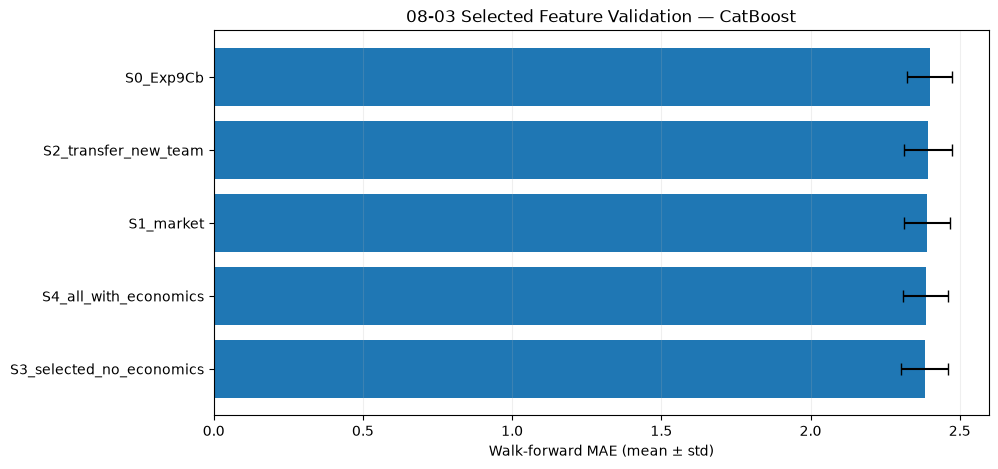

In [27]:
cat_plot = (
    catboost_summary
    .sort_values(
        "mae_mean",
        ascending=True,
    )
)

plt.figure(
    figsize=(10, 5)
)

plt.barh(
    cat_plot[
        "experiment"
    ],
    cat_plot[
        "mae_mean"
    ],
    xerr=cat_plot[
        "mae_std"
    ],
    capsize=4,
)

plt.xlabel(
    "Walk-forward MAE "
    "(mean ± std)"
)

plt.title(
    "08-03 Selected Feature Validation — CatBoost"
)

plt.grid(
    axis="x",
    alpha=0.2,
)

plt.show()

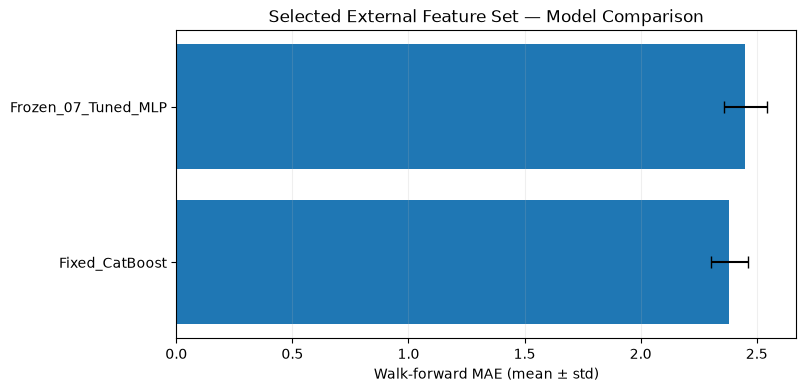

In [28]:
selected_plot = (
    model_summary[
        model_summary[
            "experiment"
        ].eq(
            "S3_selected_no_economics"
        )
    ]
    .sort_values(
        "mae_mean"
    )
)

plt.figure(
    figsize=(8, 4)
)

plt.barh(
    selected_plot[
        "model"
    ],
    selected_plot[
        "mae_mean"
    ],
    xerr=selected_plot[
        "mae_std"
    ],
    capsize=4,
)

plt.xlabel(
    "Walk-forward MAE "
    "(mean ± std)"
)

plt.title(
    "Selected External Feature Set — Model Comparison"
)

plt.grid(
    axis="x",
    alpha=0.2,
)

plt.show()

# Part I. 결과 저장

In [29]:
ARTIFACT_DIR = Path(
    "artifacts"
)

ARTIFACT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

OUTPUTS = {
    "catboost_results": (
        ARTIFACT_DIR
        / "08_03_catboost_selected_ablation_results.csv"
    ),

    "catboost_summary": (
        ARTIFACT_DIR
        / "08_03_catboost_selected_ablation_summary.csv"
    ),

    "all_model_results": (
        ARTIFACT_DIR
        / "08_03_model_revalidation_results.csv"
    ),

    "model_summary": (
        ARTIFACT_DIR
        / "08_03_model_revalidation_summary.csv"
    ),

    "model_improvement": (
        ARTIFACT_DIR
        / "08_03_selected_feature_model_improvement.csv"
    ),

    "predictions": (
        ARTIFACT_DIR
        / "08_03_model_revalidation_predictions.csv"
    ),
}

catboost_results.to_csv(
    OUTPUTS[
        "catboost_results"
    ],
    index=False,
)

catboost_summary.to_csv(
    OUTPUTS[
        "catboost_summary"
    ],
    index=False,
)

all_results.to_csv(
    OUTPUTS[
        "all_model_results"
    ],
    index=False,
)

model_summary.to_csv(
    OUTPUTS[
        "model_summary"
    ],
    index=False,
)

model_improvement.to_csv(
    OUTPUTS[
        "model_improvement"
    ],
    index=False,
)

all_predictions.to_csv(
    OUTPUTS[
        "predictions"
    ],
    index=False,
)

for name, path in (
    OUTPUTS.items()
):
    print(
        f"{name:<22}",
        path.resolve(),
    )

catboost_results       D:\dev\03_PersonalProjects\next_season_goal_prediction\notebooks\artifacts\08_03_catboost_selected_ablation_results.csv
catboost_summary       D:\dev\03_PersonalProjects\next_season_goal_prediction\notebooks\artifacts\08_03_catboost_selected_ablation_summary.csv
all_model_results      D:\dev\03_PersonalProjects\next_season_goal_prediction\notebooks\artifacts\08_03_model_revalidation_results.csv
model_summary          D:\dev\03_PersonalProjects\next_season_goal_prediction\notebooks\artifacts\08_03_model_revalidation_summary.csv
model_improvement      D:\dev\03_PersonalProjects\next_season_goal_prediction\notebooks\artifacts\08_03_selected_feature_model_improvement.csv
predictions            D:\dev\03_PersonalProjects\next_season_goal_prediction\notebooks\artifacts\08_03_model_revalidation_predictions.csv


## 21. 최종 protocol 저장

In [30]:
FINAL_PROTOCOL = {
    "data_min_target_year": 2017,

    "outer_validation_seasons": (
        OUTER_VAL_SEASONS
    ),

    "test_status": (
        "LOCKED / NOT LOADED"
    ),

    "selected_feature_hypothesis": {
        "keep": (
            SELECTED_EXTERNAL
        ),
        "exclude": (
            TRANSFER_ECONOMIC_FEATURES
        ),
    },

    "catboost": {
        "type": (
            "fixed baseline"
        ),
        "params": (
            FIXED_CATBOOST_PARAMS
        ),
    },

    "mlp": {
        "type": (
            "frozen 07 tuned params"
        ),
        "params_source": (
            str(
                MLP_PARAMS_PATH
            )
        ),
        "epoch": (
            "recalibrated inside each Outer Train"
        ),
        "numeric_missing": (
            "train median imputation"
        ),
    },
}

protocol_path = (
    ARTIFACT_DIR
    / "08_03_selected_external_protocol.json"
)

with protocol_path.open(
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        FINAL_PROTOCOL,
        f,
        ensure_ascii=False,
        indent=2,
    )

print(
    protocol_path.resolve()
)

D:\dev\03_PersonalProjects\next_season_goal_prediction\notebooks\artifacts\08_03_selected_external_protocol.json


# 22. 결과 해석 — 직접 작성

아래는 **의도적으로 비워둡니다.**

---

## A. Feature Set 확정

1. S3는 S0보다 평균 MAE가 낮은가?
2. S3는 4개 Fold 중 몇 개에서 S0를 이기는가?
3. S3는 S4보다 좋은가?
4. Transfer Economics를 제외하는 결정이 지지되는가?
5. S1 Market과 S2 Transfer+NewTeam 중 어느 쪽 signal이 더 강한가?
6. S3는 Worst Fold / std도 안정적인가?
7. 실제 이적 선수 MAE는 개선되는가?
8. 고득점자 MAE/Bias는 얼마나 변하는가?

### 내 결론

- S3 vs S0:
- S3 vs S4:
- Market signal:
- Transfer/New-Team signal:
- Transfer Economics:
- 최종 Selected Feature Set:
- Feature 조합 탐색 종료 여부:

---

## B. CatBoost vs 07 Tuned MLP

1. Exp9Cb에서는 두 모델 중 누가 좋은가?
2. S3를 추가했을 때 각각 얼마나 개선되는가?
3. MLP도 external feature의 도움을 받는가?
4. S3 기준 MAE / RMSE / R² 1위 모델은?
5. 고득점자는 어느 모델이 덜 과소예측하는가?
6. 실제 이적 선수는 어느 모델이 더 잘 예측하는가?
7. MLP의 best epoch가 Fold별로 여전히 크게 다른가?

### 내 결론

- CatBoost S3:
- MLP S3:
- 전체 성능 기준:
- 고득점자 기준:
- 이적 선수 기준:
- 현재 최종 후보 모델:
- 재-HPO 필요 여부:

---

## C. 다음 결정

08-03 이후에는 다음 중 하나를 선택합니다.

### 1) Selected External이 명확히 유효
```text
Selected Feature Set 확정
↓
필요한 모델만 HPO
↓
09 Model A / Model B
```

### 2) 개선이 너무 작고 불안정
```text
Exp9Cb 또는 단순 Market Feature 유지
↓
추가 feature 조합 탐색 종료
↓
09 Model A / Model B
```

고득점자 문제는 별도의 objective / loss / 추가 데이터 문제로 분리합니다.

# 다음 단계 후보

## 09. Two-stage Modeling

현재 조건부 회귀의 한계를 해결하기 위해:

```text
Model A
P(다음 시즌 Big5 기록 존재)

Model B
E(다음 시즌 득점 | Big5 기록 존재)
```

로 나눕니다.

08에서 구축한 external snapshot은 Model A에서도 그대로 재사용할 수 있습니다.

특히 Model A에서는:

- destination_in_big5
- confirmed preseason transfer
- market value
- age
- current playing time
- current performance

등이 직접적인 signal 후보가 됩니다.

---

### 별도 연구 주제

고득점자 과소예측은 Two-stage 여부와 별개로 남아 있으므로 이후:

- weighted loss
- target transform
- Poisson / count regression
- two-head objective
- playing-time decomposition
- role / penalty / injury 데이터

등의 별도 가설로 다룹니다.